# import

In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm


# MNISTを使った数字認識

## GPUの利用

In [2]:
# デバイスの割り当て
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


cuda:0


## データ準備1（データセットによる読み込み）
- データ入手：Dataset（データセット）
- データ加工：Transforms
- ミニバッチ用データセット作成：DataLoader（データローダー）

### MNISTデータの取得
`train_set0`は，Pythonのリストのように（入力データ，正解データ）のセットを順に取得できる．

In [3]:
# import torchvision.datasets as datasets

data_root = './data' # ダウンロード先ディレクトリ名

train_set0 = datasets.MNIST(
    root=data_root, # 元データダウンロード先の指定
    train=True, # 訓練データか検証データか
    download=True # 元データがない場合にダウンロードするか
)
print(type(train_set0))


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.53MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]

<class 'torchvision.datasets.mnist.MNIST'>


### 読み込んだファイルの確認結果

In [4]:
!ls -lR ./data/MNIST

# .gz → ダウンロードしたファイル
# .ubyte → 実際に使うデータ


./data/MNIST:
total 4
drwxr-xr-x 2 root root 4096 May 13 01:39 raw

./data/MNIST/raw:
total 65008
-rw-r--r-- 1 root root  7840016 May 13 01:39 t10k-images-idx3-ubyte
-rw-r--r-- 1 root root  1648877 May 13 01:39 t10k-images-idx3-ubyte.gz
-rw-r--r-- 1 root root    10008 May 13 01:39 t10k-labels-idx1-ubyte
-rw-r--r-- 1 root root     4542 May 13 01:39 t10k-labels-idx1-ubyte.gz
-rw-r--r-- 1 root root 47040016 May 13 01:39 train-images-idx3-ubyte
-rw-r--r-- 1 root root  9912422 May 13 01:39 train-images-idx3-ubyte.gz
-rw-r--r-- 1 root root    60008 May 13 01:39 train-labels-idx1-ubyte
-rw-r--r-- 1 root root    28881 May 13 01:39 train-labels-idx1-ubyte.gz


### 訓練用データセットの確認

In [5]:
# データ件数の確認
print('訓練データの件数:', len(train_set0))

# 最初の要素の取得
image, label = train_set0[0]

# データ型の確認
print("入力データの型:", type(image))
print("正解データの型:", type(label))


訓練データの件数: 60000
入力データの型: <class 'PIL.Image.Image'>
正解データの型: <class 'int'>


### 最初の要素の確認
入力データの画像を表示

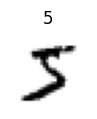

In [6]:
plt.figure(figsize=(1, 1))
plt.title(f'{label}')
plt.imshow(image, cmap='gray_r')
plt.axis('off')
plt.show()


### 複数の画像を正解ラベル付きで表示

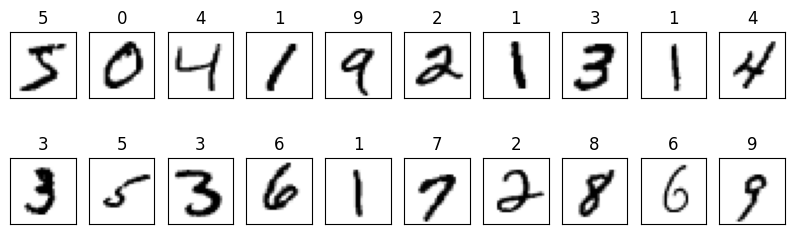

In [7]:
plt.figure(figsize=(10, 3))
for i in range(20):
    ax = plt.subplot(2, 10, i + 1)

    # imageとlabelの取得
    image, label = train_set0[i]

    # 画像の表示
    plt.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## データ準備2（Transformsによるデータ前処理）

### Step1. ToTensorの利用
ToTensorクラスは，入力データの形式をPyTorchのテンソル形式へ変換する機能を持っている．

In [8]:
# import torchvision.transforms as transforms

# Compose = 変換処理のパイプライン
transform1 = transforms.Compose([
    # データのテンソル化
    transforms.ToTensor(),
])

train_set1 = datasets.MNIST(
    root=data_root, # 元データダウンロード先の指定
    train=True, # 訓練データか検証データか
    download=True, # 元データがない場合にダウンロードするか
    transform=transform1
)


In [9]:
# 変換結果の確認
image, label = train_set1[0]
print("入力データの型:", type(image)) # テンソルに変換されている事を確認
print("入力データのshape:", image.shape)
print("最小値:", image.data.min())
print("最大値:", image.data.max())


入力データの型: <class 'torch.Tensor'>
入力データのshape: torch.Size([1, 28, 28])
最小値: tensor(0.)
最大値: tensor(1.)


### Step2. Normalizeの利用
データ範囲を$[0, 1]$から$[-1, 1]$へ変換したいものとする．
`Normalize(μ, σ)`は，元のデータ$x$を$X = (x - \mu) / \sigma$へ変換する．

In [10]:
transform2 = transforms.Compose([
    transforms.ToTensor(), # データのテンソル化
    transforms.Normalize(0.5, 0.5) # データの正規化
])

train_set2 = datasets.MNIST(
    root=data_root, # 元データダウンロード先の指定
    train=True, # 訓練データか検証データか
    download=True, # 元データがない場合にダウンロードするか
    transform=transform2
)


In [11]:
# 変換結果の確認
image, label = train_set2[0]
print("入力データの型:", type(image)) # テンソルに変換されている事を確認
print("入力データのshape:", image.shape)
print("最小値:", image.data.min())
print("最大値:", image.data.max())


入力データの型: <class 'torch.Tensor'>
入力データのshape: torch.Size([1, 28, 28])
最小値: tensor(-1.)
最大値: tensor(1.)


### Step3. Lambdaクラスを利用して1次元化
部品が提供されていない変換を実装したい時は，やりたい変換をラムダ式に書いてLambdaクラスの引数に渡せばよい．

In [12]:
transform3 = transforms.Compose([
    transforms.ToTensor(), # データのテンソル化
    transforms.Normalize(0.5, 0.5), # データの正規化
    transforms.Lambda(lambda x: x.view(-1)), # テンソルの1階テンソル化
])

train_set3 = datasets.MNIST(
    root=data_root, # 元データダウンロード先の指定
    train=True, # 訓練データか検証データか
    download=True, # 元データがない場合にダウンロードするか
    transform=transform3
)


In [ ]:
# 変換結果の確認
image, label = train_set3[0]
print("入力データの型:", type(image)) # テンソルに変換されている事を確認
print("入力データのshape:", image.shape)
print("最小値:", image.data.min())
print("最大値:", image.data.max())


入力データの型: <class 'torch.Tensor'>
入力データのshape: torch.Size([784])
最小値: tensor(-1.)
最大値: tensor(1.)


### 最終的なTransformsの定義
教科書では，`train=False`の場合を検証データ扱いしていたけど，それではテストデータが存在しなくなるため独自に改変しているよ．

In [14]:
# 訓練用Transforms
train_transform = transforms.Compose([
    transforms.ToTensor(), # データのテンソル化
    transforms.Normalize(0.5, 0.5), # データの正規化
    transforms.Lambda(lambda x: x.view(-1)), # データの1階テンソル化
])

# 検証・テスト用Transforms
eval_transform = transforms.Compose([
    transforms.ToTensor(), # データのテンソル化
    transforms.Normalize(0.5, 0.5), # データの正規化
    transforms.Lambda(lambda x: x.view(-1)), # データの1階テンソル化
])

# 元になるデータセット
train_set_full = datasets.MNIST(root=data_root, train=True, download=True, transform=train_transform) # 訓練用フィルタ
valid_set_full = datasets.MNIST(root=data_root, train=True, download=True, transform=eval_transform) # 検証・テスト用フィルタ

# 訓練データと検証データのサイズを定義
train_size = int(len(train_set_full) * 0.9)
valid_size = len(train_set_full) - train_size

# データを分割するための「ランダムなインデックス」を生成
torch.manual_seed(42)
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.MNIST(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


54000
6000
10000


## データ準備3（データローダーによるミニバッチ用データ生成）

In [ ]:
# from torch.utils.data import DataLoader

# ミニバッチのサイズ指定
batch_size = 500

# データローダー
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True) # 訓練用なので，シャッフルをかける．
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=False) # 検証時にシャッフルは不要
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)


In [16]:
# データローダーのテスト
print(len(train_loader))

# データローダーから最初の1セットを取得する．ミニバッチが正しく得られる事をきちんと確認しよう．
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break


108
torch.Size([500, 784])
torch.Size([500])


## モデル定義

### 入力・出力次元数の定義

In [17]:
for images, labels in train_loader:
    break

# 入力次元数
n_input = images[0].shape[0]

# 出力次元数（分類先クラス数）
n_output = len(set(list(labels.detach().numpy())))

# 隠れ層のノード数
n_hidden = 128

print(f"n_input: {n_input}, n_hidden: {n_hidden}, n_output: {n_output}")


n_input: 784, n_hidden: 128, n_output: 10


### モデルクラスの定義
784入力10出力1隠れ層のNNモデル

In [ ]:
class Net(nn.Module):
    def __init__(self, n_input, n_output, n_hidden):
        super().__init__()

        self.l1 = nn.Linear(n_input, n_hidden) # 隠れ層
        self.l2 = nn.Linear(n_hidden, n_output) # 出力層

        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.relu(x1)
        x3 = self.l2(x2)
        return x3


### モデルのインスタンス化

In [19]:
# 乱数の固定化
torch.manual_seed(123)
torch.cuda.manual_seed(123)

# モデルのインスタンス化してGPUへ送る．
net = Net(n_input=n_input, n_output=n_output, n_hidden=n_hidden).to(device)

print(net)


Net(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU(inplace=True)
)


### モデル内パラメータの確認

In [ ]:
for name, param in net.named_parameters():
    print(name, param.device)


l1.weight cuda:0
l1.bias cuda:0
l2.weight cuda:0
l2.bias cuda:0


## 勾配降下法

### 初期化処理

In [21]:
torch.manual_seed(123)
torch.cuda.manual_seed(123)

lr = 0.01

criterion = nn.CrossEntropyLoss() # 損失関数：交差エントロピー関数
optimizer = optim.SGD(net.parameters(), lr=lr) # 最適化関数：勾配降下法

num_epochs = 100

history = np.zeros((0, 5))


### 学習ループ

In [22]:
for epoch in range(num_epochs):
    loss_train, acc_train = 0, 0
    loss_valid, acc_valid = 0, 0
    n_train, n_valid = 0, 0

    # 訓練フェーズ
    for inputs, labels in tqdm(train_loader):
        train_batch_size = len(labels) # 1バッチあたりのデータ件数
        n_train += train_batch_size # 1エポックあたりのデータ累積件数

        # GPUへ転送
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 勾配の初期化
        outputs = net(inputs) # 予測計算
        loss = criterion(outputs, labels) # 損失計算
        loss.backward() # 勾配計算
        optimizer.step() # パラメータ更新

        # 平均前の損失と正解数の計算
        # lossは平均計算が行われているので平均前の損失に戻して加算
        loss_train += loss.item() * train_batch_size
        values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
        acc_train += (indices == labels).sum().item()
    
    # 予測フェーズ
    with torch.no_grad():
        for inputs, labels in valid_loader:
            valid_batch_size = len(labels) # 1バッチあたりのデータ件数
            n_valid += valid_batch_size # 1エポックあたりのデータ累積件数

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs) # 予測計算
            loss = criterion(outputs, labels) # 損失計算

            # 平均前の損失と正解数の計算
            # lossは平均計算が行われているので平均前の損失に戻して加算
            loss_valid += loss.item() * valid_batch_size
            values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号
            acc_valid += (indices == labels).sum().item()
    
    loss_train /= n_train
    acc_train /= n_train
    loss_valid /= n_valid
    acc_valid /= n_valid

    print(f"Epoch [{epoch+1}/{num_epochs}], loss_train: {loss_train}, acc_train: {acc_train}, loss_valid: {loss_valid}, acc_valid: {acc_valid}")
    item = np.array([epoch+1, loss_train, acc_train, loss_valid, acc_valid])
    history = np.vstack((history, item))


  0%|          | 0/108 [00:00<?, ?it/s]

Epoch [1/100], loss_train: 1.87747844170641, acc_train: 0.552, loss_valid: 1.4298674960931141, acc_valid: 0.7506666666666667


  0%|          | 0/108 [00:00<?, ?it/s]

Epoch [2/100], loss_train: 1.1193027551527377, acc_train: 0.7867222222222222, loss_valid: 0.8882492582003275, acc_valid: 0.8186666666666667


  0%|          | 0/108 [00:00<?, ?it/s]

...

Epoch [98/100], loss_train: 0.17728057752052942, acc_train: 0.9506666666666667, loss_valid: 0.20156424616773924, acc_valid: 0.9401666666666667


  0%|          | 0/108 [00:00<?, ?it/s]

Epoch [99/100], loss_train: 0.17619849500004892, acc_train: 0.9510740740740741, loss_valid: 0.20061562210321426, acc_valid: 0.9418333333333333


  0%|          | 0/108 [00:00<?, ?it/s]

Epoch [100/100], loss_train: 0.17511078080645315, acc_train: 0.9512222222222222, loss_valid: 0.19950120771924654, acc_valid: 0.9415


## 結果確認

In [23]:
print(f'初期状態: 損失: {history[0,3]:.5f}, 精度: {history[0,4]:.5f}')
print(f'最終状態: 損失: {history[-1,3]:.5f}, 精度: {history[-1,4]:.5f}')


初期状態: 損失: 1.42987, 精度: 0.75067
最終状態: 損失: 0.19950, 精度: 0.94150


### 学習曲線

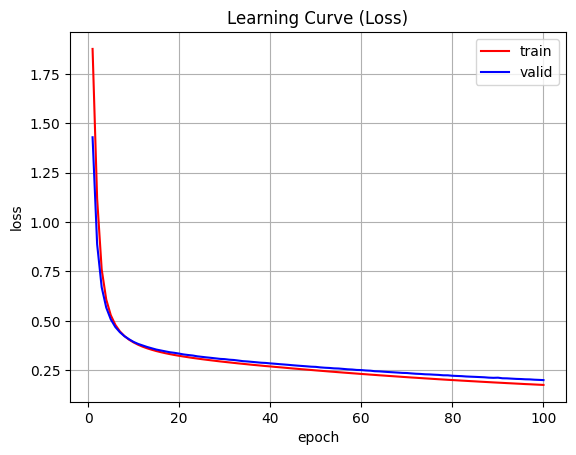

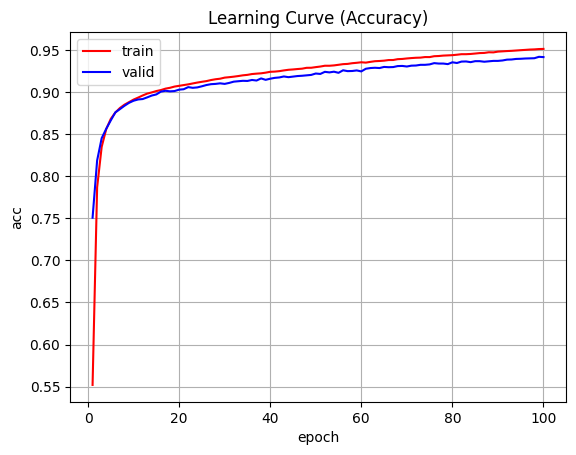

In [24]:
plt.plot(history[:, 0], history[:, 1], c='r', label='train')
plt.plot(history[:, 0], history[:, 3], c='b', label='valid')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("Learning Curve (Loss)")
plt.legend()
plt.grid()
plt.show()

plt.plot(history[:, 0], history[:, 2], c='r', label='train')
plt.plot(history[:, 0], history[:, 4], c='b', label='valid')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.title("Learning Curve (Accuracy)")
plt.legend()
plt.grid()
plt.show()


### 画像を表示して確認

In [28]:
# DataLoaderから最初の1セットを取得
for images, labels in test_loader:
    break

# 予測結果の取得
inputs = images.to(device)
labels = labels.to(device)
outputs = net(inputs)
values, indices = torch.max(outputs, dim=1) # 最大値・クラス番号

print(indices.shape)

torch.Size([500])


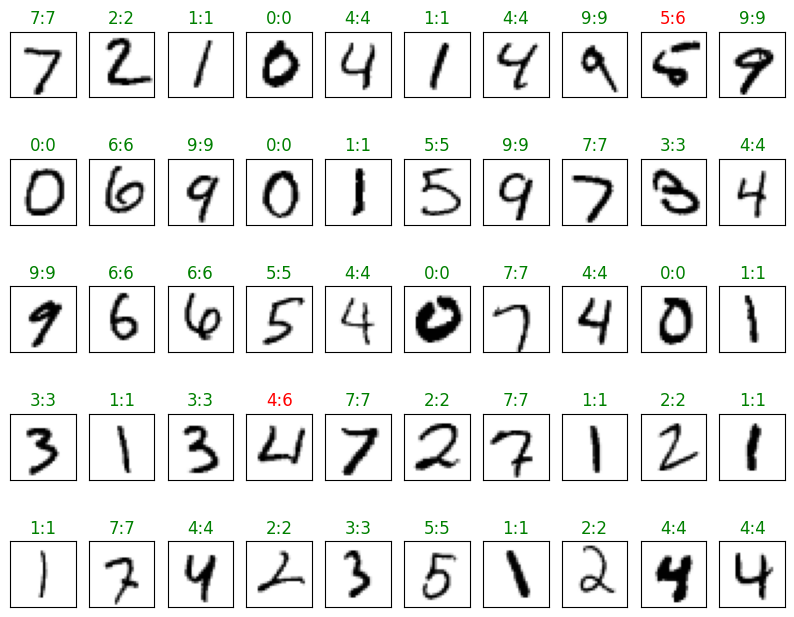

In [30]:
# 最初の50件で画像と「正解値:予測値」を表示

plt.figure(figsize=(10, 8))
for i in range(50):
    ax = plt.subplot(5, 10, i + 1)

    # ndarrayに変換
    image = images[i]
    label = labels[i]
    pred = indices[i]
    if (pred == label):
        c = 'g'
    else:
        c = 'r'
    
    # imgの範囲を[0, 1]に戻す．
    image2 = (image + 1) / 2

    plt.imshow(image2.reshape(28, 28), cmap='gray_r')
    ax.set_title(f"{label}:{pred}", c=c)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


## 隠れ層の2層化